# Ablation Sweep — Run & Inspect

**TL;DR — which to use:**
- **Smoke test / single group / inspecting results** → use this notebook
- **Full sweep (~2 hours with `max_workers=8`)** → use the CLI so the kernel can't die:
  ```bash
  nohup python -m experiments.ablation > outputs/sweep.log 2>&1 &
  tail -f outputs/sweep.log
  ```

Parallelism is already wired in: `n_votes` fires concurrently inside each video,  
and `max_workers=8` (default) processes 8 videos at once within each run.

---
## 0 — Setup

In [1]:
import os, sys, time
from pathlib import Path

# ── Locate repo root ──────────────────────────────────────────────────────────
# VSCode sets __vsc_ipynb_file__ to the notebook's absolute path.
# The notebook lives at <repo>/notebooks/ablation_sweep.ipynb, so parent.parent = repo root.
if "__vsc_ipynb_file__" in dir():
    repo_root = str(Path(__vsc_ipynb_file__).parent.parent)
else:
    # Fallback: search upward AND downward one level from cwd
    def _find_repo_root() -> str:
        search = [Path.cwd()] + list(Path.cwd().parents)
        # also try children one level down
        search += [c for c in Path.cwd().iterdir() if c.is_dir()]
        for p in search:
            if (p / "pipeline").is_dir() and (p / "experiments").is_dir():
                return str(p)
        raise RuntimeError(
            f"Could not find repo root from cwd={Path.cwd()}. "
            "Open the notebook from VS Code or cd into the repo first."
        )
    repo_root = _find_repo_root()

os.chdir(repo_root)
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)
print("cwd:", os.getcwd())

# ── IMPORTANT: restart the kernel if you just edited any pipeline/*.py file ──

t0 = time.perf_counter()

from dotenv import load_dotenv
load_dotenv(os.path.join(repo_root, ".env"))
print(f"dotenv loaded ({time.perf_counter()-t0:.1f}s)")
print("  GOOGLE_APPLICATION_CREDENTIALS set:", bool(os.environ.get("GOOGLE_APPLICATION_CREDENTIALS")))
print("  GCP_PROJECT_ID:", os.environ.get("GCP_PROJECT_ID", "(not set)"))

print(f"importing config... ", end="", flush=True)
from config.settings import config
print(f"ok ({time.perf_counter()-t0:.1f}s)")

# Pipeline modules: NO GCP SDK loaded at import time (fully lazy until first API call)
print(f"importing pipeline modules... ", end="", flush=True)
from pipeline import detection, classification, ingestion
print(f"ok ({time.perf_counter()-t0:.1f}s)")

print(f"importing ablation framework... ", end="", flush=True)
from experiments.ablation import (
    BASE_CONFIG, PHASE3_BASE_CONFIG, SWEEP_ORDER, STUDY_GROUPS,
    run_study_group, compare_results,
    select_best_configs, get_pareto_front,
    run_phase1_sweep, run_phase2_augmented,
    run_full_phased_sweep, run_phase3_sweep,
)
from experiments.runner import ExperimentRunner
from evaluation.metrics import evaluate
print(f"ok ({time.perf_counter()-t0:.1f}s)")

OUTPUTS = "outputs"
GT      = "data/dataset_mapping.xlsx"

print(f"\nAll imports done in {time.perf_counter()-t0:.1f}s")
print("Sweep order:", SWEEP_ORDER)

cwd: /home/grom/DevFiles/Classes/Capstone
dotenv loaded (0.0s)
  GOOGLE_APPLICATION_CREDENTIALS set: True
  GCP_PROJECT_ID: ehs-2-490708
importing config... ok (0.0s)
importing pipeline modules... ok (0.0s)
importing ablation framework... ok (0.8s)

All imports done in 0.8s
Sweep order: ['C', 'D', 'F', 'B', 'A', 'E']


---
## 1 — Smoke test (1 config per group, quick sanity check)

Run this first to confirm auth, pricing tables, and metrics output are all wired correctly.  
Takes ~5–10 minutes.

In [ ]:
# Smoke test: 1 config per group, 15 videos, n_votes=1
# ~2-3 minutes vs ~13 minutes for the full 73-video run
smoke_dirs = run_full_phased_sweep(
    n_top=2,
    outputs_dir=OUTPUTS,
    max_configs_per_group=1,
    base_config={
        **BASE_CONFIG,
        "n_votes": 1,        # 1 vote instead of 3 → 3× fewer Stage 1 calls
        "max_videos": 15,    # 15 videos instead of 73
    },
)

---
## 2 — Run a single group interactively

Good for iterating on a specific axis without running the full sweep.

In [ ]:
# Change group_id to whichever you want: C, D, F, B, A, E
group_dirs = run_study_group(
    group_id="C",
    outputs_dir=OUTPUTS,
)

---
## 3 — Full Phase 1 sweep (all groups, originals only)

~2 hours with `max_workers=8`. Consider running from the CLI instead:
```bash
nohup python -m experiments.ablation > outputs/sweep.log 2>&1 &
```
But if you want notebook output:

In [ ]:
phase1_results = run_phase1_sweep(outputs_dir=OUTPUTS)

  Processing: VID010
  Processing: VID011
  Processing: VID012
  Processing: VID013
  Processing: VID014
  Processing: VID015
  Processing: VID016


---
## 4 — Compare results across any set of runs

In [ ]:
import glob

# All Phase 1 runs
all_phase1 = sorted(glob.glob(f"{OUTPUTS}/*phase1_*"))
print(f"Found {len(all_phase1)} Phase 1 runs")
compare_results(all_phase1)

In [ ]:
# Just Group C runs
group_c_dirs = sorted(glob.glob(f"{OUTPUTS}/*phase1_C_*"))
compare_results(group_c_dirs)

---
## 5 — Select best configs for Phase 2 (Pareto: F1 vs cost)

In [ ]:
import glob

all_phase1 = sorted(glob.glob(f"{OUTPUTS}/*phase1_*"))

best_configs = select_best_configs(
    all_phase1,
    n=5,
    primary_metric="binary_f1",
    include_pareto=True,   # also adds cost-efficient Pareto-optimal configs
)

---
## 6 — Phase 2: run best configs on augmented videos

In [ ]:
phase2_dirs = run_phase2_augmented(best_configs, outputs_dir=OUTPUTS)
compare_results(phase2_dirs)

---
## 7 — Generate PDF report for any run

In [ ]:
from evaluation.visualize import generate_report

# Change this to any run directory
run_dir = sorted(glob.glob(f"{OUTPUTS}/*phase1_C_*"))[0]
print("Generating report for:", run_dir)

generate_report(
    predictions_jsonl=f"{run_dir}/predictions.jsonl",
    gt_excel=GT,
    output_path=f"{run_dir}/report.pdf",
    run_id=os.path.basename(run_dir),
)
print("Done:", f"{run_dir}/report.pdf")

---
## 8 — Quick metrics table (all completed runs, sorted by binary F1)

In [10]:
import json, glob
import pandas as pd

rows = []
for d in sorted(glob.glob(f"{OUTPUTS}/*")):
    mp = f"{d}/metrics.json"
    if not os.path.exists(mp):
        continue
    with open(mp) as f:
        m = json.load(f)
    rows.append({
        "run": os.path.basename(d),
        "binary_f1":   round(m.get("binary_f1", float("nan")), 3),
        "macro_f1":    round(m.get("macro_f1", float("nan")), 3),
        "binary_rec":  round(m.get("binary_recall", float("nan")), 3),
        "binary_pre":  round(m.get("binary_precision", float("nan")), 3),
        "latency_s":   round(m.get("mean_latency_s", float("nan")), 1),
        "cost_usd":    round(m.get("total_cost_usd", float("nan")), 6),
        "vehicle_f1":  round((m.get("per_class_f1") or {}).get("Vehicle Incident", float("nan")), 3),
        "trip_f1":     round((m.get("per_class_f1") or {}).get("Trip", float("nan")), 3),
        "struck_f1":   round((m.get("per_class_f1") or {}).get("Struck by Object", float("nan")), 3),
    })

df = pd.DataFrame(rows).sort_values("binary_f1", ascending=False).reset_index(drop=True)
pd.set_option("display.max_colwidth", 60)
df

,run,binary_f1,macro_f1,binary_rec,binary_pre,latency_s,cost_usd,vehicle_f1,trip_f1,struck_f1
0,20260319_071147_phase1_A_026,0.941,0.635,0.930,0.952,14.9,0.021411,0.0,0.400,0.500
1,20260319_070154_phase1_A_020,0.938,0.611,0.927,0.950,11.0,0.020697,0.0,0.286,0.500
2,20260319_070947_phase1_A_025,0.929,0.624,0.907,0.951,12.2,0.021261,0.0,0.444,0.400
3,20260319_070513_phase1_A_022,0.929,0.621,0.907,0.951,9.3,0.021261,0.0,0.222,0.545
4,20260319_112821_phase2_A_020,0.929,0.688,0.907,0.951,12.1,0.021261,0.0,0.500,0.600
...,...,...,...,...,...,...,...,...,...,...
66,20260319_051856_phase1_F_003,0.843,0.553,0.814,0.875,7.2,0.013519,0.0,0.250,0.000
67,20260319_055242_phase1_B_008,0.842,0.547,0.744,0.970,9.6,0.030135,0.0,0.250,0.000
68,20260319_060234_phase1_A_006,0.833,0.676,0.769,0.909,17.5,0.014892,0.0,0.500,0.286
69,20260319_105909_phase1_E_003,0.811,0.614,0.714,0.938,16.2,0.087416,0.0,0.500,0.000


---
## 9 — Run a one-off custom config (without YAML)

In [ ]:
from experiments.runner import ExperimentRunner

runner = ExperimentRunner({
    **BASE_CONFIG,
    "name":                    "custom_test",
    "outputs_dir":             OUTPUTS,
    "binary_prompt_variant":   "high_recall",
    "stage1_model":            "gemini-2.5-flash-lite",
    "n_votes":                 1,
    "confidence_threshold":    0.0,
    "max_workers":             8,
})
runner.run()

---
## 10 — Analysis & Export for Sponsor Report

Loads every completed run's `metrics.json` + `config_snapshot.yaml` into a single
DataFrame, then produces:

- **Excel workbook** — one sheet per group + summary sheets (ready to attach to a report)
- **Pareto front** — cost vs binary-F1 scatter, highlights the efficient frontier
- **Parameter impact** — per-group bar charts showing which axis value won
- **Robustness** — Phase 1 (originals) vs Phase 2 (augmented) F1 side-by-side

In [11]:
"""10a — Load all runs into a single DataFrame (run this first)."""
import glob, json, re, os
import yaml
import pandas as pd

def load_all_runs(outputs_dir: str = "outputs") -> pd.DataFrame:
    """Load metrics + config for every completed run under outputs_dir."""
    rows = []
    for d in sorted(glob.glob(f"{outputs_dir}/*")):
        mp = os.path.join(d, "metrics.json")
        cp = os.path.join(d, "config_snapshot.yaml")
        if not os.path.exists(mp):
            continue

        with open(mp) as f:
            m = json.load(f)
        cfg = {}
        if os.path.exists(cp):
            with open(cp) as f:
                cfg = yaml.safe_load(f) or {}

        run_name = os.path.basename(d)
        gm = re.search(r"phase(\d+)_([A-Z])_", run_name)
        pcf = (m.get("per_class_f1") or {})

        rows.append({
            "run":            run_name,
            "phase":          int(gm.group(1)) if gm else None,
            "group":          gm.group(2)      if gm else None,
            # ── Core metrics ──────────────────────────────────────────────────
            "binary_f1":      m.get("binary_f1"),
            "macro_f1":       m.get("macro_f1"),
            "binary_recall":  m.get("binary_recall"),
            "binary_prec":    m.get("binary_precision"),
            "cost_usd":       m.get("total_cost_usd"),
            "latency_s":      m.get("mean_latency_s"),
            "n_videos":       m.get("n_videos"),
            "n_failed":       m.get("n_failed"),
            # ── Per-class F1 ──────────────────────────────────────────────────
            "f1_vehicle":     pcf.get("Vehicle Incident"),
            "f1_trip":        pcf.get("Trip"),
            "f1_struck":      pcf.get("Struck by Object"),
            # ── Key config axes ───────────────────────────────────────────────
            "model":          cfg.get("model"),
            "stage1_model":   cfg.get("stage1_model"),
            "binary_prompt":  cfg.get("binary_prompt_variant"),
            "class_prompt":   cfg.get("classification_prompt_variant"),
            "temperature":    cfg.get("temperature"),
            "n_votes":        cfg.get("n_votes"),
            "vote_policy":    cfg.get("vote_policy"),
            "conf_threshold": cfg.get("confidence_threshold"),
        })

    df = pd.DataFrame(rows)
    print(f"Loaded {len(df)} runs")
    if not df.empty:
        print(df.groupby(["phase", "group"])["binary_f1"].count().unstack("phase").fillna(0).astype(int))
    return df

df_all = load_all_runs(OUTPUTS)

Loaded 71 runs
phase   1  2
group       
A      27  4
B       9  2
C       6  0
D      10  0
E       4  0
F       8  1


In [12]:
"""10b — Export to Excel (multi-sheet workbook for sponsor appendix)."""

export_path = os.path.join(OUTPUTS, "ablation_results_summary.xlsx")

phase1 = df_all[df_all["phase"] == 1].copy()
phase2 = df_all[df_all["phase"] == 2].copy()

METRIC_COLS = ["binary_f1", "macro_f1", "binary_recall", "binary_prec",
               "cost_usd", "latency_s", "f1_vehicle", "f1_trip", "f1_struck",
               "n_videos", "n_failed"]
CONFIG_COLS = ["model", "stage1_model", "binary_prompt", "class_prompt",
               "temperature", "n_votes", "vote_policy", "conf_threshold"]
DISPLAY_COLS = ["run", "group"] + METRIC_COLS + CONFIG_COLS

def _fmt(df):
    return df[DISPLAY_COLS].sort_values("binary_f1", ascending=False).reset_index(drop=True)

with pd.ExcelWriter(export_path, engine="openpyxl") as writer:
    # ── Summary sheets ────────────────────────────────────────────────────────
    _fmt(phase1).to_excel(writer, sheet_name="Phase1 All",       index=False)
    _fmt(phase2).to_excel(writer, sheet_name="Phase2 Augmented", index=False)

    # Best config per group
    if not phase1.empty:
        best = phase1.loc[phase1.groupby("group")["binary_f1"].idxmax()]
        _fmt(best).to_excel(writer, sheet_name="Best Per Group", index=False)

    # ── One sheet per group ───────────────────────────────────────────────────
    for g in sorted(phase1["group"].dropna().unique()):
        grp_df = phase1[phase1["group"] == g]
        _fmt(grp_df).to_excel(writer, sheet_name=f"Group {g}", index=False)

    # ── Auto-fit column widths ─────────────────────────────────────────────────
    for sheet in writer.sheets.values():
        for col in sheet.columns:
            max_len = max((len(str(c.value or "")) for c in col), default=8)
            sheet.column_dimensions[col[0].column_letter].width = min(max_len + 2, 30)

print(f"Exported → {export_path}")

Exported → outputs/ablation_results_summary.xlsx


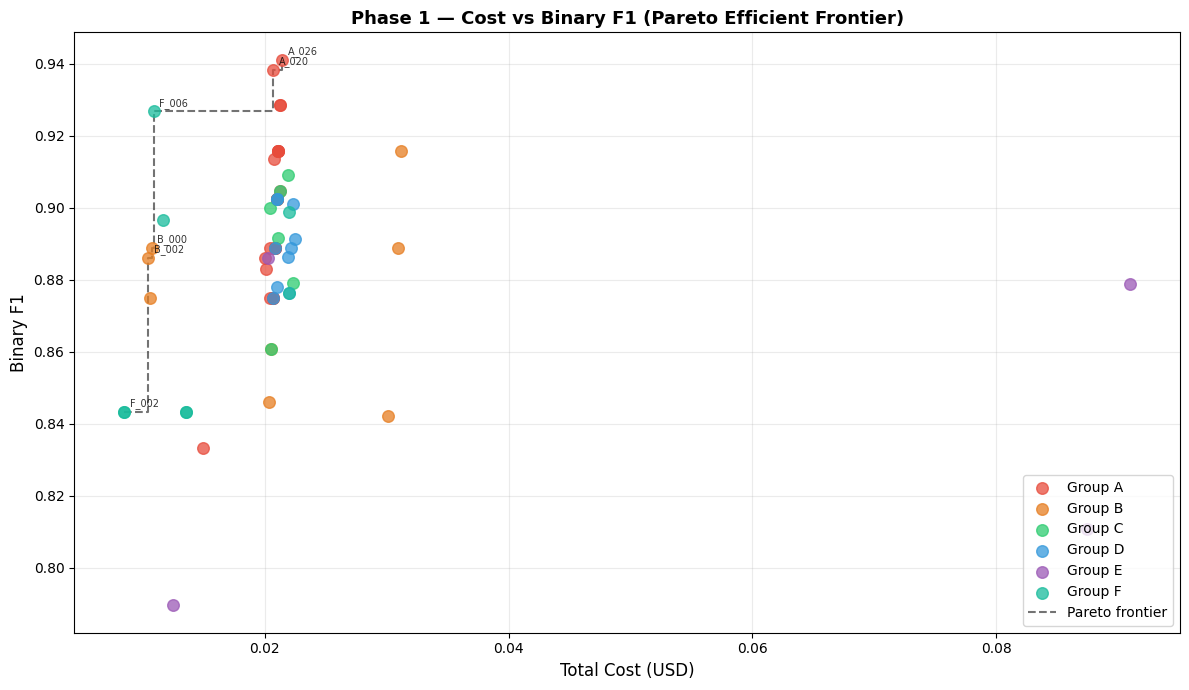

Saved → outputs/pareto_front.png


In [13]:
"""10c — Pareto front: cost vs binary-F1 (which configs are on the efficient frontier?)."""
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np

GROUP_COLORS = {"A": "#e74c3c", "B": "#e67e22", "C": "#2ecc71",
                "D": "#3498db", "E": "#9b59b6", "F": "#1abc9c"}

p1 = df_all[(df_all["phase"] == 1)].dropna(subset=["binary_f1", "cost_usd"])

fig, ax = plt.subplots(figsize=(12, 7))

for g, grp in p1.groupby("group"):
    ax.scatter(grp["cost_usd"], grp["binary_f1"],
               c=GROUP_COLORS.get(g, "gray"), label=f"Group {g}",
               s=70, alpha=0.75, zorder=3)

# ── Draw Pareto front (min cost for each F1 level) ───────────────────────────
sorted_pts = p1.sort_values("cost_usd")
pareto, best_f1 = [], -1.0
for _, row in sorted_pts.iterrows():
    if row["binary_f1"] > best_f1:
        best_f1 = row["binary_f1"]
        pareto.append(row)

if len(pareto) >= 2:
    px = [r["cost_usd"]   for r in pareto]
    py = [r["binary_f1"]  for r in pareto]
    ax.step(px, py, where="post", color="black", lw=1.5,
            linestyle="--", alpha=0.55, label="Pareto frontier", zorder=2)
    # Label Pareto points
    for r in pareto:
        label = re.search(r"phase\d+_([A-Z]_\d+)", r["run"])
        label = label.group(1) if label else ""
        ax.annotate(label, (r["cost_usd"], r["binary_f1"]),
                    textcoords="offset points", xytext=(4, 4), fontsize=7, alpha=0.8)

ax.set_xlabel("Total Cost (USD)", fontsize=12)
ax.set_ylabel("Binary F1", fontsize=12)
ax.set_title("Phase 1 — Cost vs Binary F1 (Pareto Efficient Frontier)",
             fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=10)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS, "pareto_front.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved → outputs/pareto_front.png")

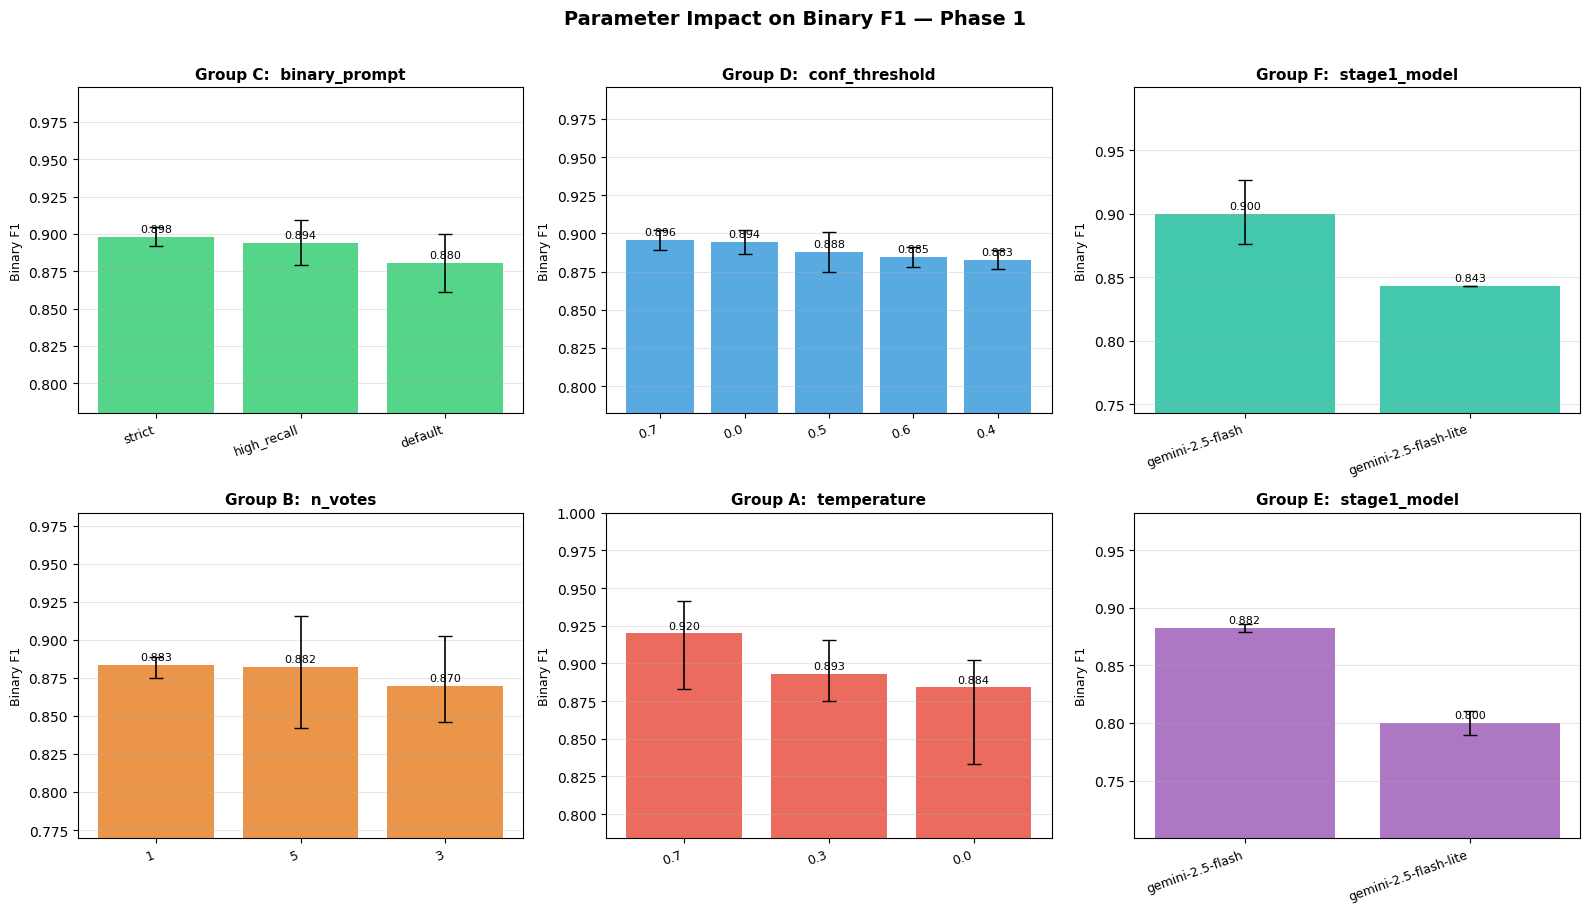

Saved → outputs/parameter_impact.png


In [14]:
"""10d — Parameter impact: which axis value drove the best F1 in each group?"""
import matplotlib.pyplot as plt

# Primary axis to highlight per group (the main thing each group was testing)
PRIMARY_AXIS = {
    "C": "binary_prompt",
    "D": "conf_threshold",
    "F": "stage1_model",
    "B": "n_votes",
    "A": "temperature",
    "E": "stage1_model",
}
SECONDARY_AXIS = {
    "C": "class_prompt",
    "D": "binary_prompt",
    "F": "n_votes",
    "B": "vote_policy",
    "A": "top_p",
    "E": "model",
}

p1 = df_all[df_all["phase"] == 1].dropna(subset=["binary_f1"])
groups = [g for g in ["C", "D", "F", "B", "A", "E"] if g in p1["group"].values]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, g in enumerate(groups):
    ax = axes[i]
    grp = p1[p1["group"] == g]
    param = PRIMARY_AXIS.get(g)

    if param and param in grp.columns:
        agg = (grp.groupby(param)["binary_f1"]
                  .agg(mean="mean", lo="min", hi="max")
                  .reset_index()
                  .sort_values("mean", ascending=False))
        labels = agg[param].astype(str)
        x = range(len(agg))
        bars = ax.bar(x, agg["mean"], color=GROUP_COLORS.get(g, "#95a5a6"), alpha=0.82)
        ax.errorbar(x, agg["mean"],
                    yerr=[agg["mean"] - agg["lo"], agg["hi"] - agg["mean"]],
                    fmt="none", color="black", capsize=5, linewidth=1.2)
        ax.set_xticks(list(x))
        ax.set_xticklabels(labels, rotation=20, ha="right", fontsize=9)
        ax.set_ylim(max(0, agg["mean"].min() - 0.1), min(1.0, agg["mean"].max() + 0.1))
        ax.set_ylabel("Binary F1", fontsize=9)
        ax.set_title(f"Group {g}:  {param}", fontweight="bold", fontsize=11)
        ax.grid(axis="y", alpha=0.3)
        ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=8)
    else:
        ax.set_visible(False)

for j in range(len(groups), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Parameter Impact on Binary F1 — Phase 1", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS, "parameter_impact.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved → outputs/parameter_impact.png")

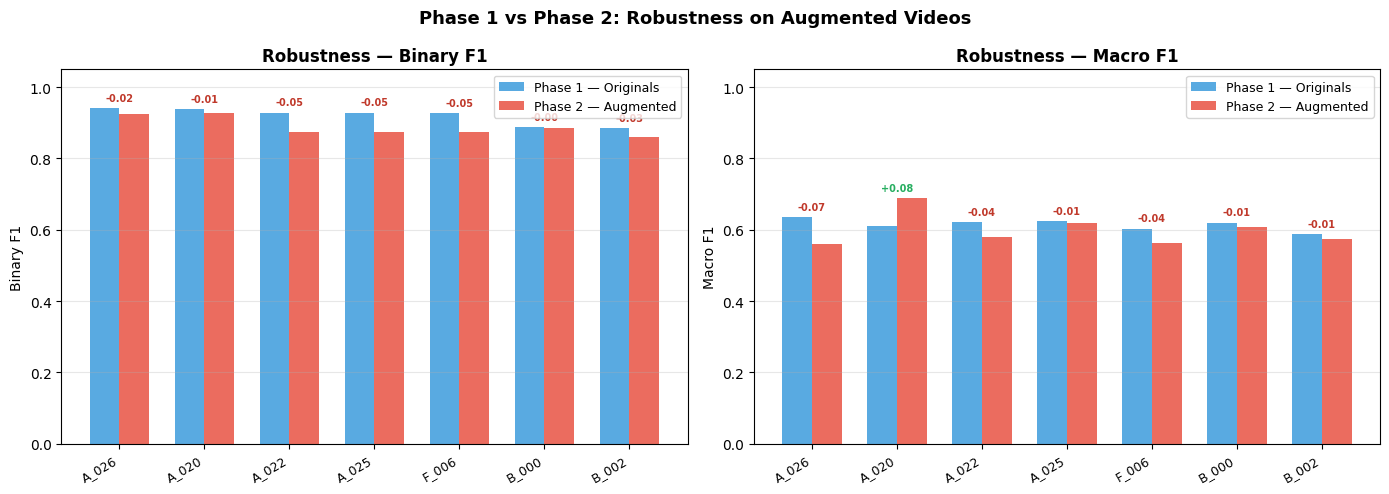

Saved → outputs/robustness_comparison.png


,Config,P1 BinF1,P2 BinF1,P1 MacF1,P2 MacF1,ΔBinF1,ΔMacF1
0,A_026,0.941176,0.925926,0.634836,0.561111,-0.015,-0.074
1,A_020,0.938272,0.928571,0.610630,0.688364,-0.010,0.078
2,A_022,0.928571,0.875000,0.621277,0.580892,-0.054,-0.040
3,A_025,0.928571,0.875000,0.623796,0.618044,-0.054,-0.006
4,F_006,0.926829,0.873563,0.603334,0.562704,-0.053,-0.041
5,B_000,0.888889,0.886076,0.619978,0.608282,-0.003,-0.012
6,B_002,0.886076,0.860759,0.586655,0.574115,-0.025,-0.013


In [15]:
"""10e — Robustness: Phase 1 (originals) vs Phase 2 (augmented) F1 comparison."""
import matplotlib.pyplot as plt

p2 = df_all[df_all["phase"] == 2].dropna(subset=["binary_f1"]).copy()
p1 = df_all[df_all["phase"] == 1].dropna(subset=["binary_f1"]).copy()

# Match by config key: "A_026" part of the run name
def _config_key(run_name):
    m = re.search(r"phase\d+_([A-Z]_\d+)", run_name)
    return m.group(1) if m else None

p2["config_key"] = p2["run"].apply(_config_key)
p1["config_key"] = p1["run"].apply(_config_key)

merged = p2.merge(
    p1[["config_key", "binary_f1", "macro_f1"]].rename(
        columns={"binary_f1": "p1_binary_f1", "macro_f1": "p1_macro_f1"}
    ),
    on="config_key", how="left",
).dropna(subset=["p1_binary_f1"])

if merged.empty:
    print("No matched Phase 1 ↔ Phase 2 pairs found. Check run naming.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, metric, p1_col, title in [
        (axes[0], "binary_f1",  "p1_binary_f1", "Binary F1"),
        (axes[1], "macro_f1",   "p1_macro_f1",  "Macro F1"),
    ]:
        x = range(len(merged))
        w = 0.35
        b1 = ax.bar([i - w/2 for i in x], merged[p1_col],   w, label="Phase 1 — Originals",  color="#3498db", alpha=0.82)
        b2 = ax.bar([i + w/2 for i in x], merged[metric],   w, label="Phase 2 — Augmented", color="#e74c3c", alpha=0.82)
        ax.set_xticks(list(x))
        ax.set_xticklabels(merged["config_key"], rotation=30, ha="right", fontsize=9)
        ax.set_ylim(0, 1.05)
        ax.set_ylabel(title)
        ax.set_title(f"Robustness — {title}", fontweight="bold")
        ax.legend(fontsize=9)
        ax.grid(axis="y", alpha=0.3)
        # Annotate drop/gain
        for i, (v1, v2) in enumerate(zip(merged[p1_col], merged[metric])):
            delta = v2 - v1
            color = "#27ae60" if delta >= 0 else "#c0392b"
            ax.annotate(f"{delta:+.2f}", (i, max(v1, v2) + 0.02),
                        ha="center", fontsize=7, color=color, fontweight="bold")

    fig.suptitle("Phase 1 vs Phase 2: Robustness on Augmented Videos",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUTS, "robustness_comparison.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → outputs/robustness_comparison.png")

    # Summary table
    summary = merged[["config_key", "p1_binary_f1", "binary_f1", "p1_macro_f1", "macro_f1"]].copy()
    summary["binary_f1_delta"] = (summary["binary_f1"] - summary["p1_binary_f1"]).round(3)
    summary["macro_f1_delta"]  = (summary["macro_f1"]  - summary["p1_macro_f1"]).round(3)
    summary.columns = ["Config", "P1 BinF1", "P2 BinF1", "P1 MacF1", "P2 MacF1", "ΔBinF1", "ΔMacF1"]
    display(summary.reset_index(drop=True))

---

## 11 — Phase 3 Sweep (Prompt & Model Re-evaluation)

**Run after Phase 1 & 2 are complete.**

- **Group G** (6 configs): binary prompt × classification prompt, with best sampling locked in (temp=0.7, top_p=0.95, top_k=40)
- **Group H** (4 configs): flash vs Pro (Stage 2) × flash vs flash-lite (Stage 1), structured prompt fixed
- Augmented validation on top-3 Pareto configs from G+H

Estimated time: ~25–35 min with `max_workers=8`.

In [2]:
# 11a — Smoke test Phase 3 (1 config per group, 15 videos)
# Run this first to confirm the new prompt parses correctly.
from experiments.ablation import PHASE3_BASE_CONFIG

smoke_p3 = run_phase3_sweep(
    outputs_dir=OUTPUTS,
    max_configs_per_group=1,
)
print('Smoke done. G dirs:', len(smoke_p3['G']), '  H dirs:', len(smoke_p3['H']))


PHASE 3 — Prompt & model re-evaluation (G → H → augmented)

────────────────────────────────────────────────────────────

[Group G] 1 configurations
  Description: 
    binary_prompt_variant: ['default', 'strict', 'high_recall']
    classification_prompt_variant: ['default', 'structured']
  Total combinations: 6

  [1/1] phase3_G_000
    axes: {'temperature': 0.7, 'top_k': 40, 'top_p': 0.95}


/home/grom/DevFiles/Classes/Capstone/.venv/lib/python3.12/site-packages/vertexai/generative_models/_generative_models.py:433: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()


[phase3_G_000] spreadsheet mode — 73 videos
[phase3_G_000] Parallel mode — 8 workers
  Processing: VID002
  Processing: VID003
  Processing: VID001
  Processing: VID000
  Processing: VID005
  Processing: VID006
  Processing: VID004
  Processing: VID007
  Processing: VID008
  Processing: VID009
  Processing: VID010
  Processing: VID011
  Processing: VID012
  Processing: VID013
  Processing: VID014
  Processing: VID015
  Processing: VID016
  Processing: VID017
  Processing: VID018
  Processing: VID019
  Processing: VID020
  Processing: VID021
  Processing: VID022
  Processing: VID023
  Processing: VID024
  Processing: VID025
  Processing: VID026
  Processing: VID027
  Processing: VID028
  Processing: VID029
  Processing: VID030
  Processing: VID031
  Processing: VID032
  Processing: VID033
  Processing: VID034
  Processing: VID035
  Processing: VID036
  Processing: VID037
  Processing: VID038
  Processing: VID039
  Processing: VID040
  Processing: VID041
  Processing: VID042
  Processing

In [3]:
# 11b — Full Phase 3 sweep
# Groups G (6) + H (4) on 73 originals, then best 3 configs on augmented.
p3_results = run_phase3_sweep(outputs_dir=OUTPUTS)

print('\nPhase 3 complete.')
print('  G dirs:', len(p3_results['G']))
print('  H dirs:', len(p3_results['H']))
print('  Augmented dirs:', len(p3_results['augmented']))


PHASE 3 — Prompt & model re-evaluation (G → H → augmented)

────────────────────────────────────────────────────────────

[Group G] 6 configurations
  Description: 
    binary_prompt_variant: ['default', 'strict', 'high_recall']
    classification_prompt_variant: ['default', 'structured']
  Total combinations: 6

  [1/6] phase3_G_000
    axes: {'temperature': 0.7, 'top_k': 40, 'top_p': 0.95}
[phase3_G_000] spreadsheet mode — 73 videos
[phase3_G_000] Parallel mode — 8 workers
  Processing: VID006
  Processing: VID000
  Processing: VID003
  Processing: VID002
  Processing: VID005
  Processing: VID004
  Processing: VID001
  Processing: VID007
  Processing: VID008
  Processing: VID009
  Processing: VID010
  Processing: VID011
  Processing: VID012
  Processing: VID013
  Processing: VID014
  Processing: VID015
  Processing: VID016
  Processing: VID017
  Processing: VID018
  Processing: VID019
  Processing: VID020
  Processing: VID021
  Processing: VID022
  Processing: VID023
  Processing: V

/home/grom/DevFiles/Classes/Capstone/.venv/lib/python3.12/site-packages/vertexai/generative_models/_generative_models.py:433: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()


  Processing: VID008
  Processing: VID009
  Processing: VID010
  Processing: VID011
  Processing: VID012
  Processing: VID013
  Processing: VID014
  Processing: VID015
  Processing: VID016
  Processing: VID017
  Processing: VID018
  Processing: VID019
  Processing: VID020
  Processing: VID021
  Processing: VID022
  Processing: VID023
  Processing: VID024
  Processing: VID025
  Processing: VID026
  Processing: VID027
  Processing: VID028
  Processing: VID029
  Processing: VID030
  Processing: VID031
  Processing: VID032
  Processing: VID033
  Processing: VID034
  Processing: VID035
  Processing: VID036
  Processing: VID037
  Processing: VID038
  Processing: VID039
  Processing: VID040
  Processing: VID041
  Processing: VID042
  Processing: VID043
  Processing: VID044
  Processing: VID045
  Processing: VID046
  Processing: VID047
  Processing: VID048
  Processing: VID049
  Processing: VID050
  Processing: VID051
  Processing: VID052
  Processing: VID053
  Processing: VID054
  Processing:

/home/grom/DevFiles/Classes/Capstone/.venv/lib/python3.12/site-packages/vertexai/generative_models/_generative_models.py:433: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()


  Processing: VID008
  Processing: VID009
  Processing: VID010
  Processing: VID011
  Processing: VID012
  Processing: VID013
  Processing: VID014
  Processing: VID015
  Processing: VID016
  Processing: VID017
  Processing: VID018
  Processing: VID019
  Processing: VID020
  Processing: VID021
  Processing: VID022
  Processing: VID023
  Processing: VID024
  Processing: VID025
  Processing: VID026
  Processing: VID027
  Processing: VID028
  Processing: VID029
  Processing: VID030
  Processing: VID031
  Processing: VID032
  Processing: VID033
  Processing: VID034
  Processing: VID035
  Processing: VID036
  Processing: VID037
  Processing: VID038
  Processing: VID039
  Processing: VID040
  Processing: VID041
  Processing: VID042
  Processing: VID043
  Processing: VID044
  Processing: VID045
  Processing: VID046
  Processing: VID047
  Processing: VID048
  Processing: VID049
  Processing: VID050
  Processing: VID051
  Processing: VID052
  Processing: VID053
  Processing: VID054
  Processing:

/home/grom/DevFiles/Classes/Capstone/.venv/lib/python3.12/site-packages/vertexai/generative_models/_generative_models.py:433: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()


  Processing: VID008
  Processing: VID009
  Processing: VID010
  Processing: VID011
  Processing: VID012
  Processing: VID013
  Processing: VID014
  Processing: VID015
  Processing: VID016
  Processing: VID017
  Processing: VID018
  Processing: VID019
  Processing: VID020
  Processing: VID021
  Processing: VID022
  Processing: VID023
  Processing: VID024
  Processing: VID025
  Processing: VID026
  Processing: VID027
  Processing: VID028
  Processing: VID029
  Processing: VID030
  Processing: VID031
  Processing: VID032
  Processing: VID033
  Processing: VID034
  Processing: VID035
  Processing: VID036
  Processing: VID037
  Processing: VID038
  Processing: VID039
  Processing: VID040
  Processing: VID041
  Processing: VID042
  Processing: VID043
  Processing: VID044
  Processing: VID045
  Processing: VID046
  Processing: VID047
  Processing: VID048
  Processing: VID049
  Processing: VID050
  Processing: VID051
  Processing: VID052
  Processing: VID053
  Processing: VID054
  Processing:

/home/grom/DevFiles/Classes/Capstone/.venv/lib/python3.12/site-packages/vertexai/generative_models/_generative_models.py:433: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()


  Processing: VID008
  Processing: VID009
  Processing: VID010
  Processing: VID011
  Processing: VID012
  Processing: VID013
  Processing: VID014
  Processing: VID015
  Processing: VID016
  Processing: VID017
  Processing: VID018
  Processing: VID019
  Processing: VID020
  Processing: VID021
  Processing: VID022
  Processing: VID023
  Processing: VID024
  Processing: VID025
  Processing: VID026
  Processing: VID027
  Processing: VID028
  Processing: VID029
  Processing: VID030
  Processing: VID031
  Processing: VID032
  Processing: VID033
  Processing: VID034
  Processing: VID035
  Processing: VID036
  Processing: VID037
  Processing: VID038
  Processing: VID039
  Processing: VID040
  Processing: VID041
  Processing: VID042
  Processing: VID043
  Processing: VID044
  Processing: VID045
  Processing: VID046
  Processing: VID047
  Processing: VID048
  Processing: VID049
  Processing: VID050
  Processing: VID051
  Processing: VID052
  Processing: VID053
  Processing: VID054
  Processing:

In [ ]:
# 11c — Run a single Phase 3 group interactively
# Change group_id to 'G' or 'H'
p3_group_dirs = run_study_group(
    group_id='G',
    base_config=PHASE3_BASE_CONFIG,
    outputs_dir=OUTPUTS,
    name_prefix='phase3_G',
)

In [4]:
# 11d — Compare Phase 3 results against Phase 1 best
import glob, json

p1_best_dirs = sorted(glob.glob(f'{OUTPUTS}/*phase1_A_026*'))
p3_all_dirs  = sorted(glob.glob(f'{OUTPUTS}/*phase3_G*') + glob.glob(f'{OUTPUTS}/*phase3_H*'))

print('=== Phase 1 best ===')
compare_results(p1_best_dirs)

print('\n=== Phase 3 ===')
compare_results(p3_all_dirs)

=== Phase 1 best ===

Run                                            BinF1  MacF1  BinRec  BinPre Lat(s)    Cost$  Vehicl    Trip  Struck
-------------------------------------------------------------------------------------------------------------------
  20260319_071147_phase1_A_026                 0.941  0.635   0.930   0.952   14.9 0.021411   0.000   0.400   0.500

=== Phase 3 ===

Run                                            BinF1  MacF1  BinRec  BinPre Lat(s)    Cost$  Vehicl    Trip  Struck
-------------------------------------------------------------------------------------------------------------------
  20260319_141932_phase3_G_000                 0.902  0.573   0.860   0.949   19.0 0.025329   0.000   0.286   0.364
  20260319_142231_phase3_G_001                 0.905  0.680   0.884   0.927   20.3 0.025853   0.000   0.250   0.333
  20260319_142544_phase3_G_002                 0.892  0.644   0.860   0.925   19.4 0.025591   0.000   0.444   0.250
  20260319_142952_phase3_G_003  

### 11e — Phase 3 Results & Visualizations

Load Phase 3 run metrics and display the saved charts.

In [5]:
# 11e — Load Phase 3 metrics and display charts
import glob, json
import pandas as pd
from IPython.display import Image, display

def load_run(d):
    m = json.load(open(f'{d}/metrics.json'))
    import yaml
    cfg = yaml.safe_load(open(f'{d}/config_snapshot.yaml')) if __import__('os').path.exists(f'{d}/config_snapshot.yaml') else {}
    return {
        'run': __import__('os').path.basename(d),
        'binary_prompt': cfg.get('binary_prompt_variant','?'),
        'cls_prompt':    cfg.get('classification_prompt_variant','?'),
        'stage1_model':  cfg.get('stage1_model','?'),
        'stage2_model':  cfg.get('model','?'),
        'binary_f1':     m.get('binary_f1',0),
        'macro_f1':      m.get('macro_f1',0),
        'any_match':     m.get('any_match_recall', float('nan')),
        'cost':          m.get('total_cost_usd',0),
        'vehicle_f1':    m.get('per_class_f1',{}).get('Vehicle Incident',0),
        'trip_f1':       m.get('per_class_f1',{}).get('Trip',0),
        'struck_f1':     m.get('per_class_f1',{}).get('Struck by Object',0),
    }

g_rows = [load_run(d) for d in sorted(glob.glob(f'{OUTPUTS}/*phase3_G*'))]
h_rows = [load_run(d) for d in sorted(glob.glob(f'{OUTPUTS}/*phase3_H*'))]
gdf = pd.DataFrame(g_rows)
hdf = pd.DataFrame(h_rows)

print('=== Group G — Prompt Quality ===')
display(gdf[['binary_prompt','cls_prompt','binary_f1','macro_f1','any_match','vehicle_f1','trip_f1','struck_f1']].round(3))
print('\n=== Group H — Model Tier ===')
display(hdf[['stage1_model','stage2_model','binary_f1','macro_f1','any_match','cost']].round(4))

=== Group G — Prompt Quality ===


,binary_prompt,cls_prompt,binary_f1,macro_f1,any_match,vehicle_f1,trip_f1,struck_f1
0,default,default,0.902,0.573,0.581,0.0,0.286,0.364
1,default,structured,0.905,0.680,0.674,0.0,0.250,0.333
2,strict,default,0.892,0.644,0.628,0.0,0.444,0.250
3,strict,structured,0.894,0.671,0.651,0.0,0.500,0.444
4,high_recall,default,0.933,0.657,0.698,0.0,0.400,0.429
5,high_recall,structured,0.933,0.671,0.698,0.0,0.286,0.462



=== Group H — Model Tier ===


,stage1_model,stage2_model,binary_f1,macro_f1,any_match,cost
0,gemini-2.5-flash,gemini-2.5-flash,0.9157,0.6784,0.6744,0.0256
1,gemini-2.5-flash,gemini-2.5-pro,0.8916,0.6277,0.6744,0.1901
2,gemini-2.5-flash-lite,gemini-2.5-flash,0.8052,0.5771,0.5349,0.0165
3,gemini-2.5-flash-lite,gemini-2.5-pro,0.7949,0.5665,0.6047,0.1607


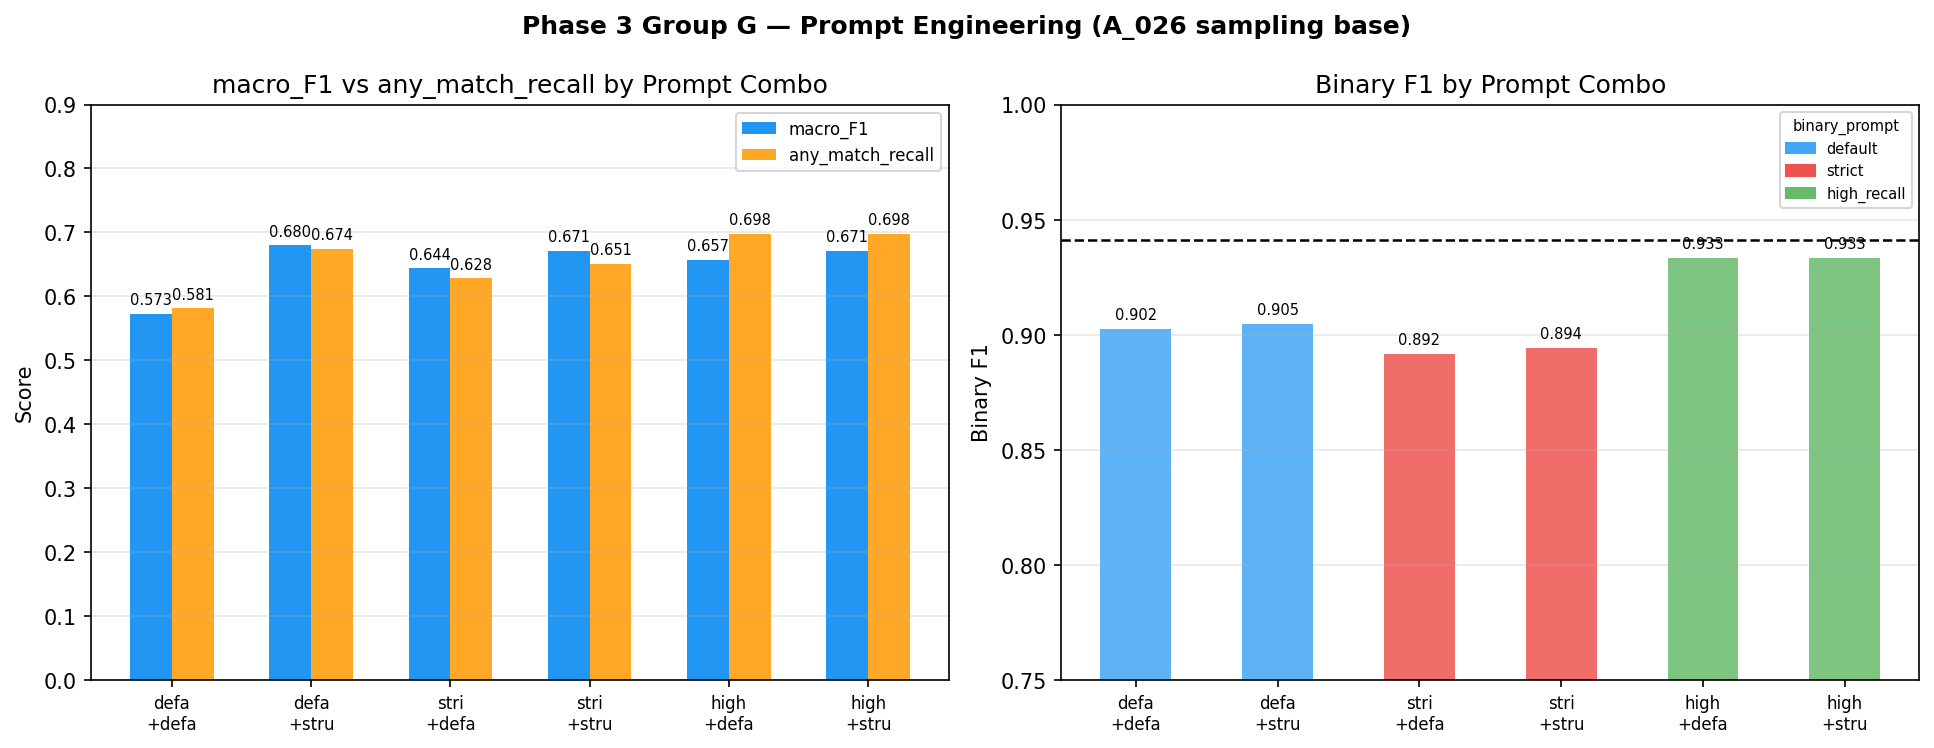

In [6]:
# Group G prompt comparison chart
display(Image('outputs/phase3_group_g.png'))

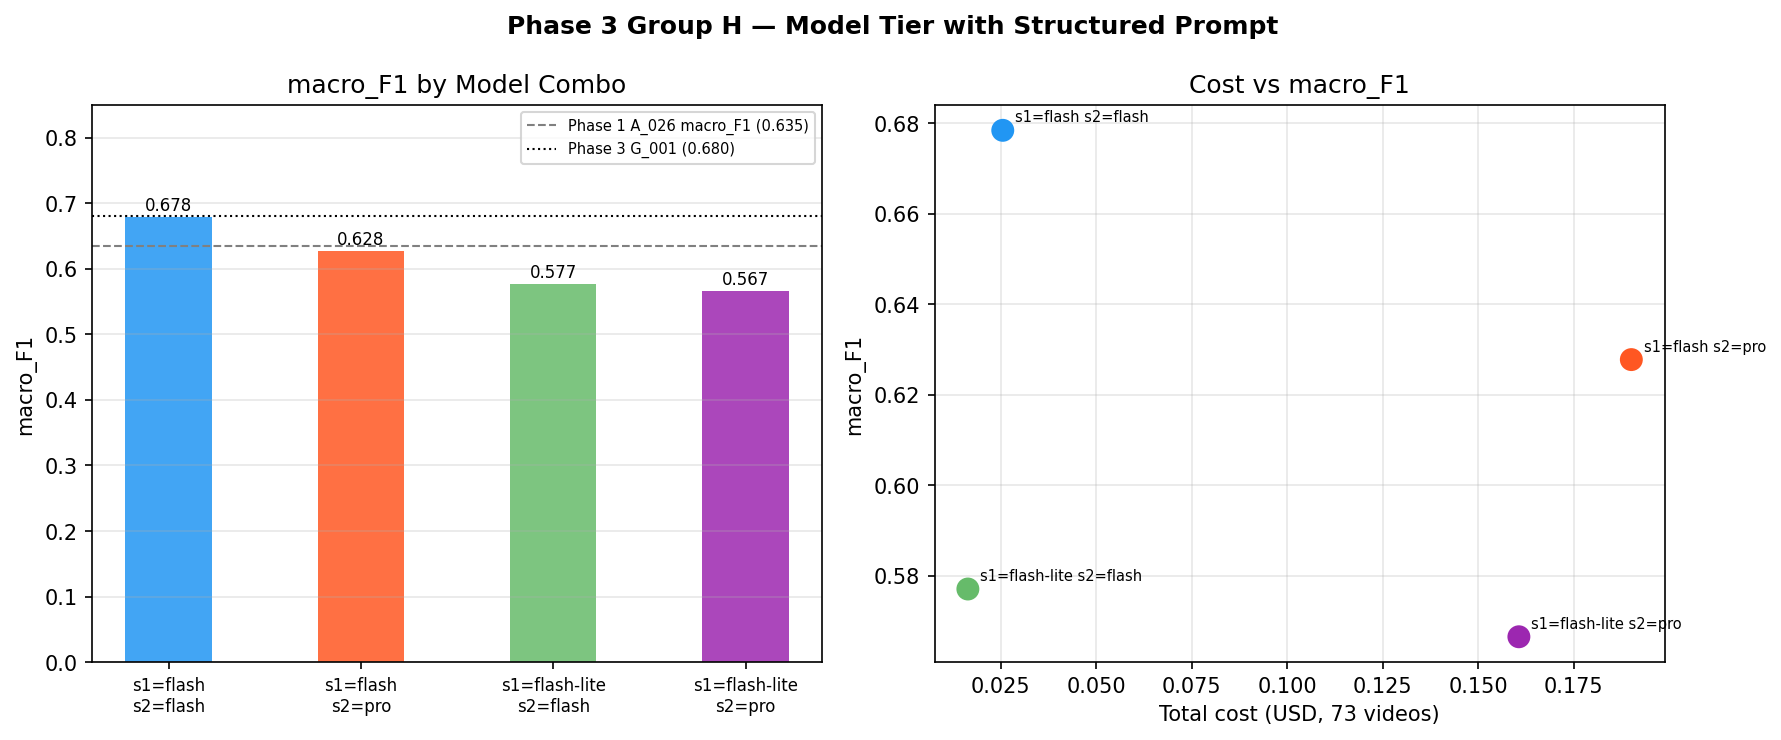

In [7]:
# Group H model tier chart
display(Image('outputs/phase3_group_h.png'))

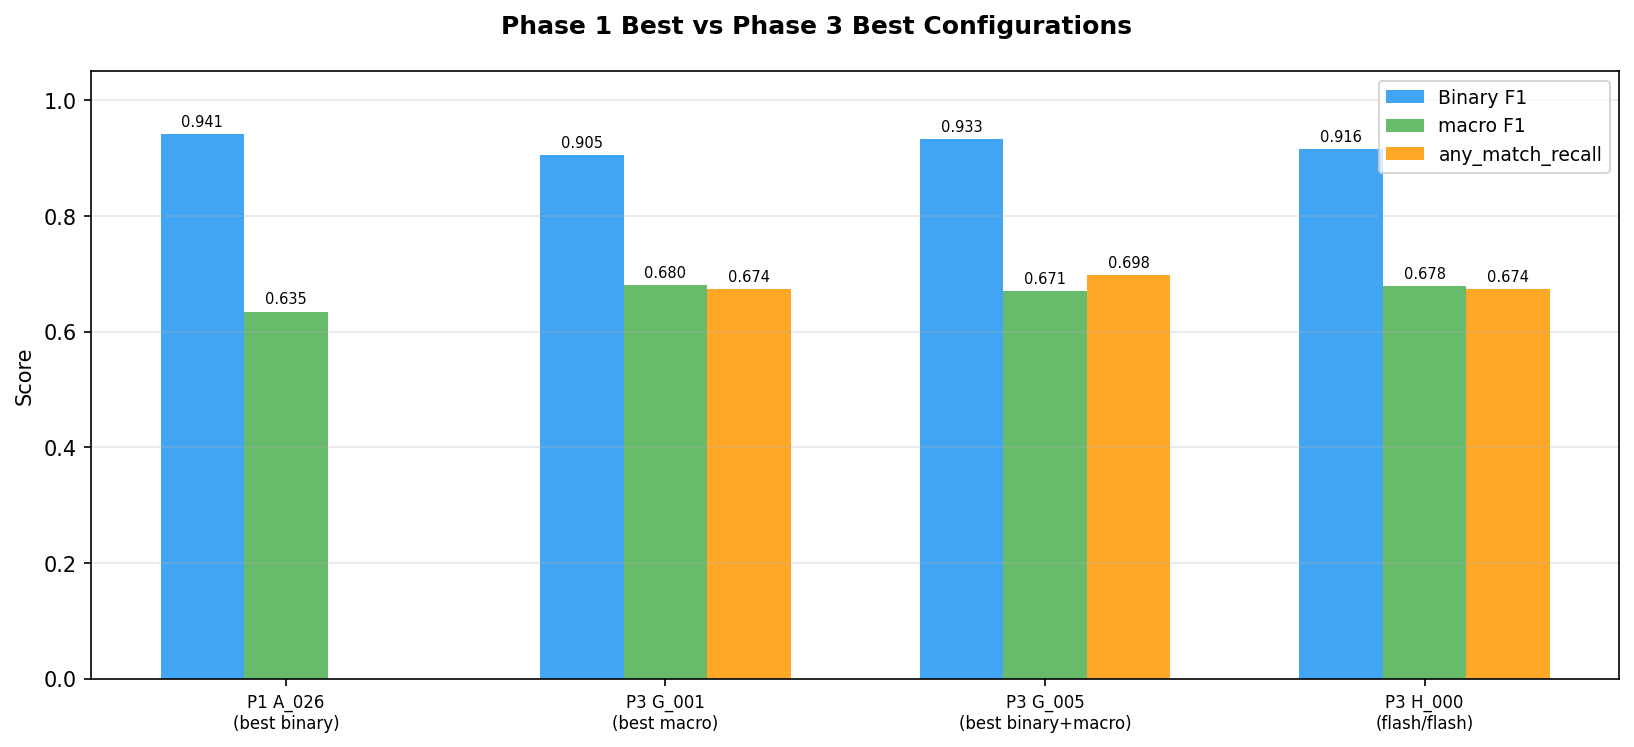

In [8]:
# Phase 1 vs Phase 3 best comparison
display(Image('outputs/phase3_comparison.png'))